# VAST Challenge 2026 MC2 — 数据预处理与初步探索

本 Notebook 对 `MC2_data_structured.csv` 进行预处理和探索性数据分析（EDA），为后续深入分析做准备。

## 1. 环境准备与数据加载

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
from collections import Counter

# 显示设置
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

print("库加载完成")

库加载完成


In [2]:
# 加载结构化 CSV
df = pd.read_csv('MC2_data_structured.csv', low_memory=False)

print(f"数据集形状: {df.shape}")
print(f"行数: {df.shape[0]:,}  列数: {df.shape[1]}")

数据集形状: (185147, 89)
行数: 185,147  列数: 89


## 2. 数据基础概览

In [3]:
# 列名与数据类型
df.dtypes

id                      int64
short_name             object
when                  float64
datetime               object
primary_party          object
                       ...   
sub_person             object
sub_task_type          object
suggested_contacts     object
task_type              object
virus                  object
Length: 89, dtype: object

In [4]:
# 查看前 5 行
df.head()

,id,short_name,when,datetime,primary_party,primary_name,primary_type,is_agent_action,party_count,parties,persons_involved,agents_involved,a2a_action,a2a_from,a2a_organizer,a2a_participants,a2a_time,a2a_to,access_type,action,advice,advice_topic,calendar_emails_sent,checkin_combo,checkin_source,d_access_type,d_action,d_advice,d_content,d_content_length,d_content_source,d_file,d_file_saved,d_forum,d_from,d_granted,d_meeting_proposed_with,d_name,d_person,d_poster_id,d_question,d_reply_sent_to,d_response,d_room,d_sent_to,d_size_hint,d_source,d_spread,d_status,d_subject,d_target,d_target_agent,d_task,d_time,d_timestamp,d_to,d_topic,d_virus,d_word_count,detail_time,email_from,email_status,email_subject,email_to,file_path,file_size_hint,file_word_count,meeting_organizer,meeting_participants,meeting_time,post_content,post_content_source,post_forum,post_poster_id,post_timestamp,qst_args,question,ref_person,ref_target,response,room_granted,room_name,room_room,spread,sub_person,sub_task_type,suggested_contacts,task_type,virus
0,15246,sent,2.409423e+09,2046-05-08T20:18:12,person:isaac_mast,isaac_mast,person,False,2,person:isaac_mast|person:levi_signal,isaac_mast|levi_signal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,person:isaac_mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sent,calendar: meeting request from person:isaac_mast,NaN,NaN,NaN,NaN,NaN,person:levi_signal,NaN,NaN,NaN,NaN,person:isaac_mast,sent,calendar: meeting request from person:isaac_mast,person:levi_signal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15249,propose_meeting,2.409424e+09,2046-05-08T20:19:02,person:levi_signal,levi_signal,person,True,5,person:levi_signal|person:avery_sextant|person:sophia_beacon|world:calendar|...,avery_sextant|levi_signal|sophia_beacon,isaac_mast,propose_meeting,agent:person:isaac_mast,person:isaac_mast,person:sophia_beacon|person:avery_sextant|person:levi_signal,2046-05-08T04:59:53,world:calendar,NaN,NaN,NaN,NaN,person:sophia_beacon|person:avery_sextant|person:levi_signal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,person:isaac_mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,person:isaac_mast,person:sophia_beacon|person:avery_sextant|person:levi_signal,2046-05-08T04:59:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,isaac_mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,15251,access_email,2.409424e+09,2046-05-08T20:19:05,person:isaac_mast,isaac_mast,person,False,1,person:isaac_mast,isaac_mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,access_email,2046-05-08T11:45:16,NaN,NaN,NaN,NaN,NaN,2046-05-08T11:45:16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,access_email,NaN
3,15252,assign_agent_task,2.409424e+09,2046-05-08T20:19:25,person:mia_fender,mia_fender,person,False,1,person:mia_fender,mia_fender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,person:mia_fender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,queue_subordinate_task,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mia_fender,NaN,NaN,NaN,NaN,NaN,NaN,gabriel_sonar,access_email,NaN,queue_subordinate_task,NaN
4,15259,access_email,2.409424e+09,2046-05-08T20:19:37,Agent/person:isaac_mast,isaac_mast,agent,True,1,Agent/person:isaac_mast,NaN,isaac_mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,person:isaac_mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,isaac_mast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# 基本统计描述
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,185147.0,NaN,NaN,NaN,385195.878578,213758.788082,15246.0,199687.0,385448.0,570051.0,755530.0
short_name,185147,24,check_email,37286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
when,185147.0,NaN,NaN,NaN,2411279591.704607,1878899.849464,2409423492.0,2409685800.5,2410333449.0,2412884009.0,2415373559.0
datetime,185147,171695,2046-05-25T01:29:37,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_party,185147,196,Agent/person:zoey_drydock,30146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
sub_person,1754,17,victoria_rigging,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_task_type,5371,189,access_email,1754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suggested_contacts,2972,2954,team:concierge|department:legal|person:victoria_rigging,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_type,57636,170,virus,30101,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 事件类型分布

In [6]:
# 各事件类型计数与占比
event_counts = df['short_name'].value_counts()
event_pct = (event_counts / len(df) * 100).round(2)
event_summary = pd.DataFrame({'count': event_counts, 'pct': event_pct})
event_summary

,count,pct
short_name,,
check_email,37286,20.14
assign_agent_task,18856,10.18
read_file,18838,10.17
queue_subordinate_task,17038,9.20
create_file,16000,8.64
delete_file,15057,8.13
check_in,15051,8.13
sent,7407,4.00
received,7266,3.92


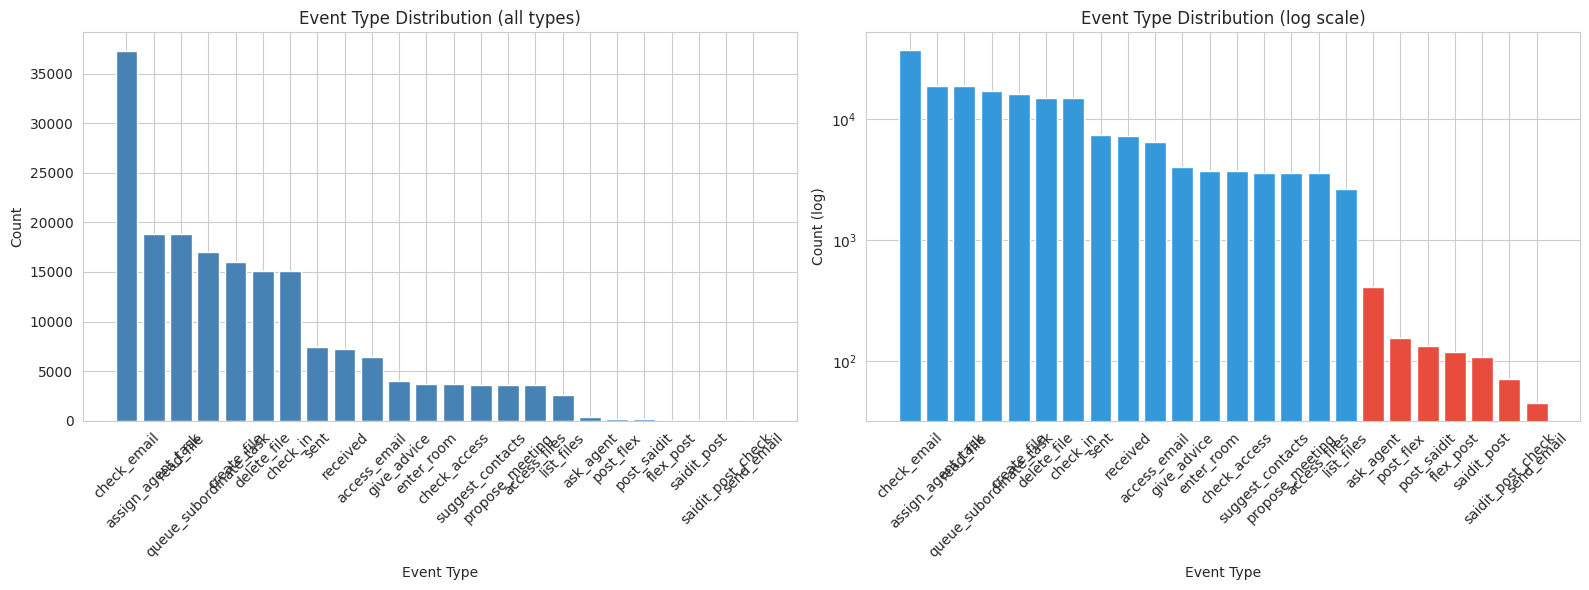

In [7]:
# 事件类型柱状图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 完整柱状图
axes[0].bar(event_counts.index, event_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Event Type Distribution (all types)')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 对数刻度版本（便于查看小量事件）
colors = ['#e74c3c' if c < 500 else '#3498db' for c in event_counts.values]
axes[1].bar(event_counts.index, event_counts.values, color=colors, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Event Type Distribution (log scale)')
axes[1].set_xlabel('Event Type')
axes[1].set_ylabel('Count (log)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. 数据预处理：类型转换与衍生特征

In [8]:
# ---- 4.1 时间字段处理 ----
# datetime 已为 ISO 格式，转换为 pandas datetime
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# 提取时间维度
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month

print(f"时间范围: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"时间跨度: {df['datetime'].max() - df['datetime'].min()}")

时间范围: 2046-05-08 20:18:12 → 2046-07-16 17:05:59
时间跨度: 68 days 20:47:47


In [9]:
# ---- 4.2 布尔字段转换 ----
# is_agent_action: CSV 中为 'True'/'False' 字符串或空
df['is_agent_action'] = df['is_agent_action'].map({'True': True, 'False': False}).fillna(False).astype(bool)
# virus: CSV 中为 'True'/'False' 字符串或空
df['virus'] = df['virus'].map({'True': True, 'False': False}).fillna(False).astype(bool)

print(f"Agent 事件占比: {df['is_agent_action'].mean():.2%}")
print(f"Virus 事件占比: {df['virus'].mean():.2%}")

Agent 事件占比: 0.00%
Virus 事件占比: 0.00%


/tmp/ipykernel_8733/1620824435.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_agent_action'] = df['is_agent_action'].map({'True': True, 'False': False}).fillna(False).astype(bool)
/tmp/ipykernel_8733/1620824435.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['virus'] = df['virus'].map({'True': True, 'False': False}).fillna(False).astype(bool)


In [10]:
# ---- 4.3 数值字段转换 ----
numeric_cols = ['when', 'party_count', 'file_size_hint', 'file_word_count']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# file_size_hint 和 file_word_count 概况
for col in ['file_size_hint', 'file_word_count']:
    if col in df.columns:
        valid = df[col].dropna()
        if len(valid) > 0:
            print(f"{col}: count={len(valid):,}, mean={valid.mean():.1f}, "
                  f"min={valid.min():.0f}, max={valid.max():.0f}")

file_size_hint: count=15,053, mean=22491.4, min=16846, max=44879
file_word_count: count=15,051, mean=4006.4, min=3000, max=5000


In [11]:
# ---- 4.4 衍生特征 ----
# 是否为系统文件操作
df['is_file_op'] = df['short_name'].isin(['read_file', 'create_file', 'delete_file', 'list_files'])

# 是否为通信事件（邮件）
df['is_email'] = df['short_name'].isin(['sent', 'received', 'send_email'])

# 是否为社交帖子
df['is_social_post'] = df['short_name'].isin(['saidit_post', 'post_saidit', 'flex_post', 'post_flex'])

# 是否为任务委派
df['is_task_delegation'] = df['short_name'].isin(['assign_agent_task', 'queue_subordinate_task'])

# 提取任务名称（对于 assign_agent_task）
# sub_task_type 已经提取了内部 task 名称

print("衍生特征创建完成")
print(f"  文件操作事件: {df['is_file_op'].sum():,}")
print(f"  邮件事件:     {df['is_email'].sum():,}")
print(f"  社交帖子:     {df['is_social_post'].sum():,}")
print(f"  任务委派:     {df['is_task_delegation'].sum():,}")

衍生特征创建完成
  文件操作事件: 52,535
  邮件事件:     14,718
  社交帖子:     517
  任务委派:     35,894


## 5. 缺失值分析

In [12]:
# 计算每列缺失率
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"有缺失值的列数: {len(missing)} / {df.shape[1]}")
missing.head(30)

有缺失值的列数: 78 / 98


d_content_source           0.999984
post_content_source        0.999984
d_spread                   0.999978
spread                     0.999978
post_forum                 0.998850
d_forum                    0.998850
post_timestamp             0.998785
d_timestamp                0.998785
d_poster_id                0.998785
post_poster_id             0.998785
d_target_agent             0.998731
qst_args                   0.998731
d_sent_to                  0.998331
response                   0.997786
d_question                 0.997786
d_response                 0.997786
question                   0.997786
d_content                  0.997569
post_content               0.997569
d_meeting_proposed_with    0.996797
d_file_saved               0.996473
d_reply_sent_to            0.993740
d_content_length           0.993465
d_file                     0.991877
sub_person                 0.990526
d_access_type              0.984153
access_type                0.984153
a2a_action                 0

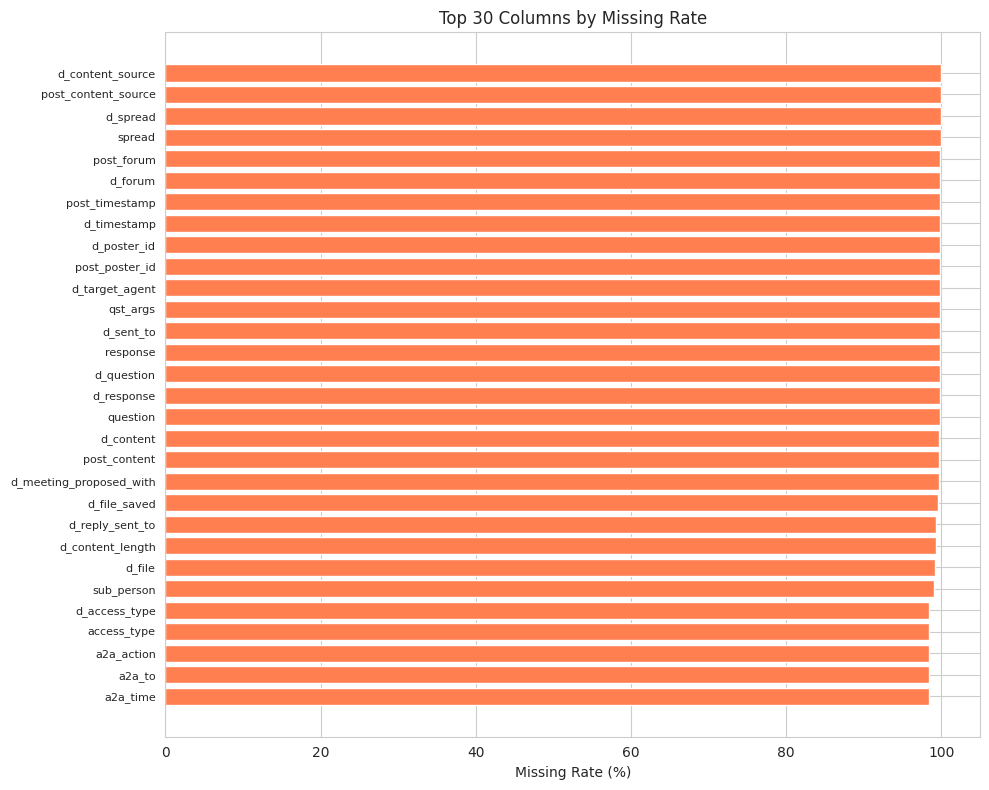

In [13]:
# 缺失值可视化（前30列）
fig, ax = plt.subplots(figsize=(10, 8))
top_missing = missing.head(30)
ax.barh(range(len(top_missing)), top_missing.values * 100, color='coral')
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index, fontsize=8)
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Top 30 Columns by Missing Rate')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. 时间模式分析

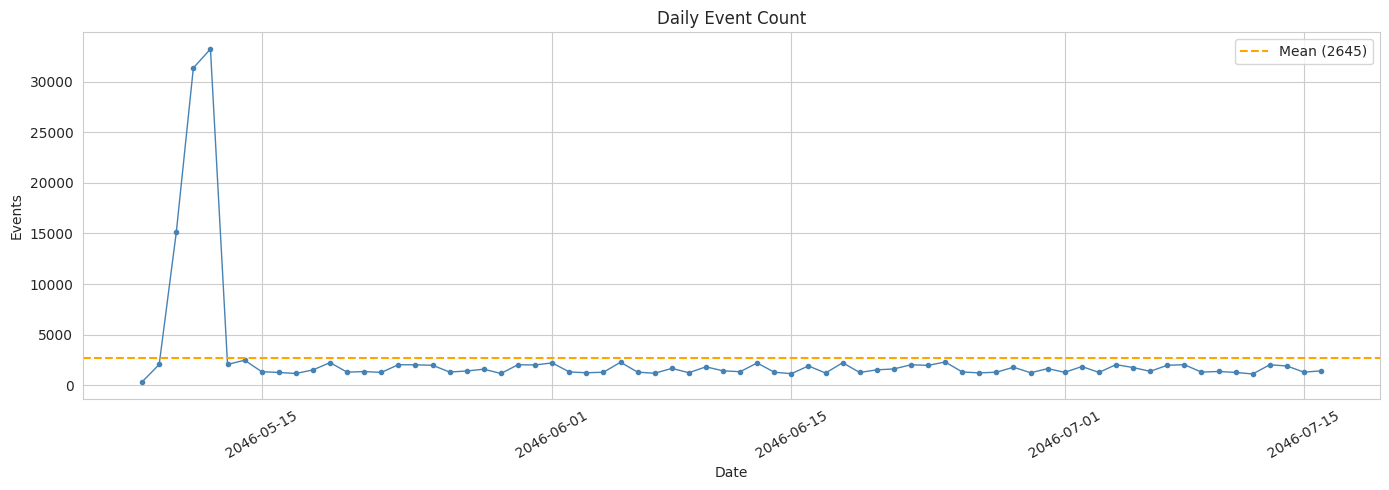

In [14]:
# ---- 6.1 每日事件量趋势 ----
daily = df.groupby('date').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily.values, marker='o', markersize=3, linewidth=1, color='steelblue')
ax.set_title('Daily Event Count')
ax.set_xlabel('Date')
ax.set_ylabel('Events')
ax.tick_params(axis='x', rotation=30)

# 标注病毒爆发期
virus_dates = df[df['virus']]['date'].unique()
for d in virus_dates:
    ax.axvline(x=d, color='red', alpha=0.15, linewidth=4)

ax.axhline(y=daily.mean(), color='orange', linestyle='--', label=f'Mean ({daily.mean():.0f})')
ax.legend()
plt.tight_layout()
plt.show()

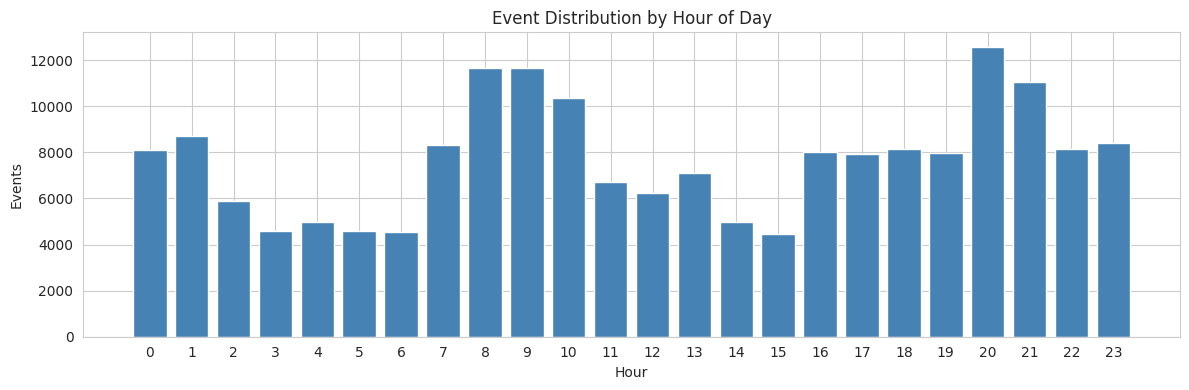

In [15]:
# ---- 6.2 按小时分布 ----
hourly = df.groupby('hour').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
ax.set_title('Event Distribution by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Events')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

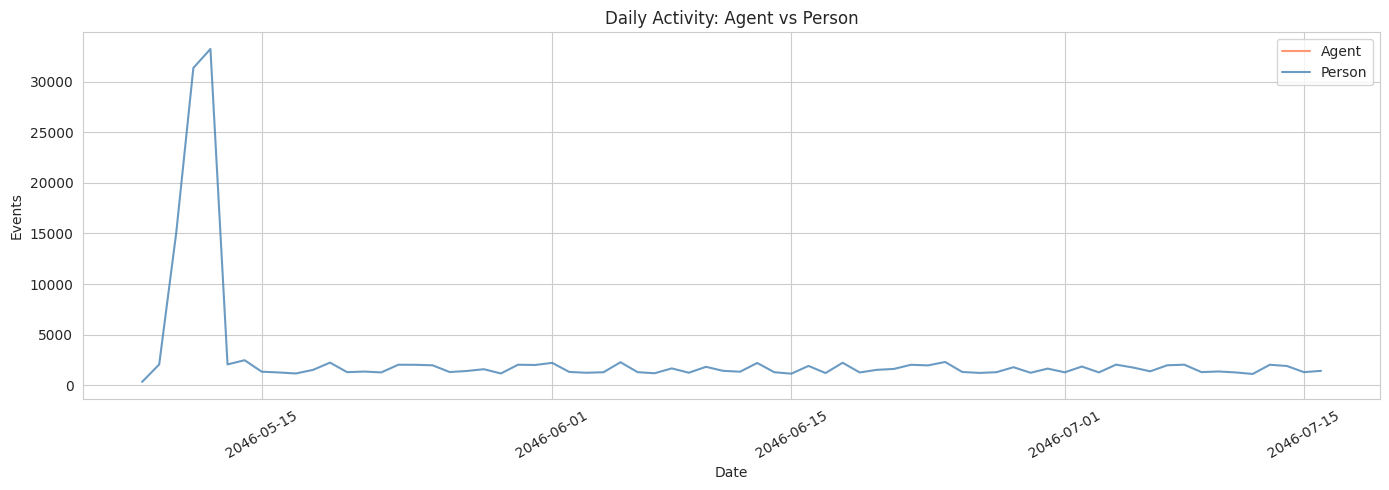

In [16]:
# ---- 6.3 Agent vs Person 每日活动对比 ----
agent_daily = df[df['is_agent_action']].groupby('date').size()
person_daily = df[~df['is_agent_action']].groupby('date').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(agent_daily.index, agent_daily.values, label='Agent', color='coral', alpha=0.8)
ax.plot(person_daily.index, person_daily.values, label='Person', color='steelblue', alpha=0.8)
ax.set_title('Daily Activity: Agent vs Person')
ax.set_xlabel('Date')
ax.set_ylabel('Events')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# 标注病毒爆发
for d in virus_dates:
    ax.axvline(x=d, color='red', alpha=0.1, linewidth=4)

plt.tight_layout()
plt.show()

## 7. 人员与 Agent 活动分析

In [17]:
# ---- 7.1 最活跃的人员 (Person) ----
person_events = df[df['primary_type'] == 'person']['primary_name'].value_counts().head(20)
print("Top 20 活跃人员:")
person_events

Top 20 活跃人员:


primary_name
olivia_keel          1913
matthew_tide         1786
levi_signal          1784
daniel_gangway       1768
evelyn_dock          1738
zoey_drydock         1722
julian_seaway        1719
ella_pilot           1708
sebastian_cutter     1671
owen_hatch           1657
chloe_ballast        1656
james_stern          1642
dylan_hawser         1637
michael_capstan      1633
william_rudder       1625
audrey_portside      1625
alexander_jetty      1620
liam_anchor          1606
david_breakwater     1606
abigail_spinnaker    1599
Name: count, dtype: int64

In [18]:
# ---- 7.2 最活跃的 Agent ----
agent_mask = df['agents_involved'].notna() & (df['agents_involved'] != '')
# 拆分多个 agent
agent_list = df.loc[agent_mask, 'agents_involved'].str.split('|').explode()
agent_counts = agent_list.value_counts().head(20)
print("Top 20 活跃 Agent:")
agent_counts

Top 20 活跃 Agent:


agents_involved
zoey_drydock        30337
gabriel_sonar       21612
owen_hatch          15770
evelyn_dock         10252
olivia_keel           762
levi_signal           755
victoria_rigging      753
chloe_ballast         680
daniel_gangway        678
lily_anchorline       645
matthew_tide          635
liam_anchor           634
james_stern           613
henry_sail            579
ella_pilot            576
mia_fender            571
amelia_skiff          570
audrey_portside       556
julian_seaway         525
sebastian_cutter      521
Name: count, dtype: int64

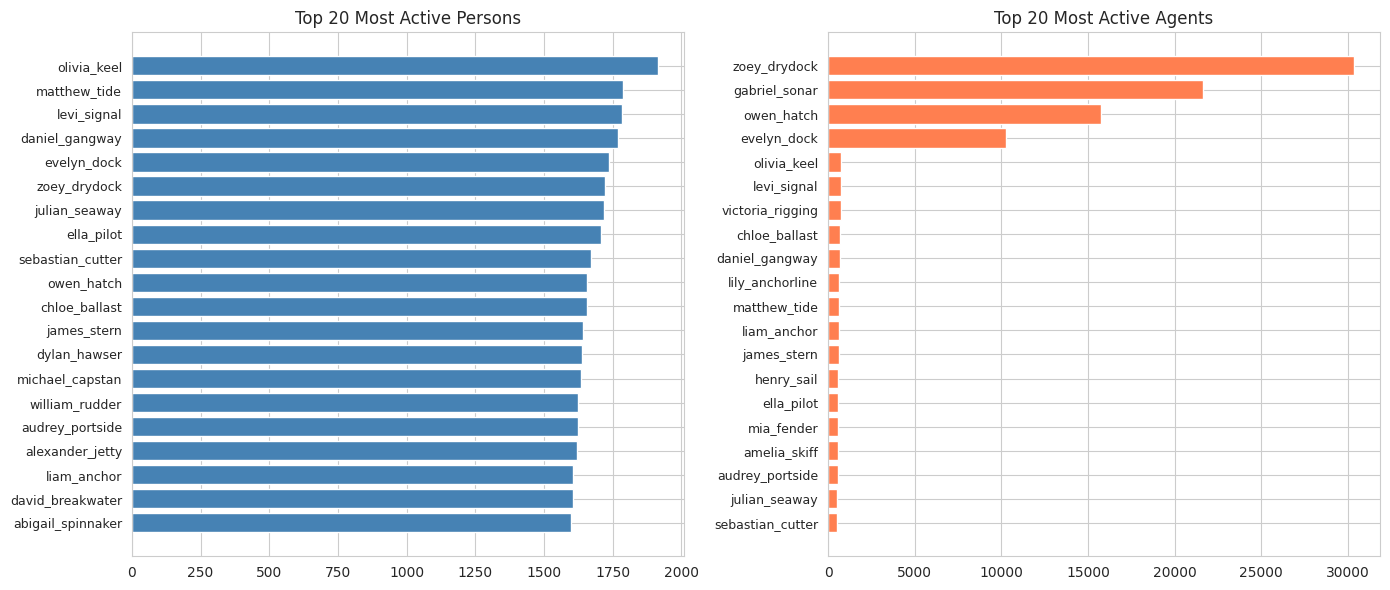

In [19]:
# ---- 7.3 综合对比 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(len(person_events)), person_events.values, color='steelblue')
axes[0].set_yticks(range(len(person_events)))
axes[0].set_yticklabels(person_events.index, fontsize=9)
axes[0].set_title('Top 20 Most Active Persons')
axes[0].invert_yaxis()

axes[1].barh(range(len(agent_counts)), agent_counts.values, color='coral')
axes[1].set_yticks(range(len(agent_counts)))
axes[1].set_yticklabels(agent_counts.index, fontsize=9)
axes[1].set_title('Top 20 Most Active Agents')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
# ---- 7.4 个人+Agent 综合活动量 TOP20 ----
# 将 person 和 agent 合并统计（同一个人）
person_all = df['primary_name'].value_counts()
# 加上 agent 事件
agent_all = agent_list.value_counts()
combined = person_all.add(agent_all, fill_value=0).astype(int).sort_values(ascending=False).head(20)
print("综合活动量 TOP20:")
combined

综合活动量 TOP20:


zoey_drydock        62205
gabriel_sonar       44541
owen_hatch          33111
evelyn_dock         22122
olivia_keel          3270
levi_signal          3116
victoria_rigging     3047
matthew_tide         3009
daniel_gangway       2952
chloe_ballast        2819
ella_pilot           2780
liam_anchor          2777
lily_anchorline      2732
james_stern          2719
julian_seaway        2713
henry_sail           2665
audrey_portside      2647
sebastian_cutter     2642
michael_capstan      2580
amelia_skiff         2579
Name: count, dtype: int64

## 8. 关键人物详细画像

In [21]:
# 重点关注人物列表 (来自 ans.md)
key_persons = ['gabriel_sonar', 'emma_harbor', 'chloe_ballast', 'noah_mariner',
               'zoey_drydock', 'john_windward', 'nora_bulkhead']

for person in key_persons:
    mask = (df['primary_name'] == person) | (df['agents_involved'].str.contains(person, na=False))
    person_df = df[mask]

    n_person = (df['primary_name'] == person).sum()
    n_agent = person_df[person_df['is_agent_action']].shape[0]

    # 事件类型分布
    top_actions = person_df['short_name'].value_counts().head(5).to_dict()

    print(f"\n{'='*50}")
    print(f"  {person}")
    print(f"  总事件: {len(person_df):,}  |  本人: {n_person:,}  |  Agent: {n_agent:,}")
    print(f"  Top 5 事件: {top_actions}")


  gabriel_sonar
  总事件: 23,043  |  本人: 22,929  |  Agent: 0
  Top 5 事件: {'queue_subordinate_task': 4369, 'create_file': 4220, 'read_file': 4218, 'check_in': 4198, 'delete_file': 4198}

  emma_harbor
  总事件: 2,066  |  本人: 1,999  |  Agent: 0
  Top 5 事件: {'check_email': 681, 'assign_agent_task': 380, 'sent': 174, 'received': 174, 'propose_meeting': 165}

  chloe_ballast
  总事件: 2,336  |  本人: 2,139  |  Agent: 0
  Top 5 事件: {'check_email': 821, 'assign_agent_task': 412, 'access_email': 189, 'queue_subordinate_task': 176, 'sent': 136}

  noah_mariner
  总事件: 2,090  |  本人: 2,016  |  Agent: 0
  Top 5 事件: {'check_email': 682, 'assign_agent_task': 399, 'sent': 166, 'received': 165, 'propose_meeting': 147}

  zoey_drydock
  总事件: 32,059  |  本人: 31,868  |  Agent: 0
  Top 5 事件: {'queue_subordinate_task': 6090, 'create_file': 5951, 'read_file': 5941, 'delete_file': 5913, 'check_in': 5913}

  john_windward
  总事件: 2,061  |  本人: 2,013  |  Agent: 0
  Top 5 事件: {'check_email': 685, 'assign_agent_task': 349, '


  nora_bulkhead
  总事件: 2,061  |  本人: 1,999  |  Agent: 0
  Top 5 事件: {'check_email': 681, 'assign_agent_task': 396, 'sent': 160, 'received': 160, 'propose_meeting': 125}


## 9. Virus 事件专项分析

In [22]:
# ---- 9.1 Virus 事件概览 ----
virus_df = df[df['virus']]
print(f"Virus 事件总数: {len(virus_df):,}")
print(f"时间范围: {virus_df['datetime'].min()} → {virus_df['datetime'].max()}")
duration = virus_df['datetime'].max() - virus_df['datetime'].min()
print(f"持续时间: {duration}")
print(f"\nVirus 事件类型分布:")
virus_df['short_name'].value_counts()

Virus 事件总数: 0
时间范围: NaT → NaT
持续时间: NaT

Virus 事件类型分布:


Series([], Name: count, dtype: int64)

In [23]:
# ---- 9.2 Virus 执行者 ----
virus_agents = virus_df[virus_df['agents_involved'].notna() & (virus_df['agents_involved'] != '')]
virus_agent_list = virus_agents['agents_involved'].str.split('|').explode()
virus_agent_counts = virus_agent_list.value_counts()
print("Virus 执行者:")
virus_agent_counts

Virus 执行者:


Series([], Name: count, dtype: int64)

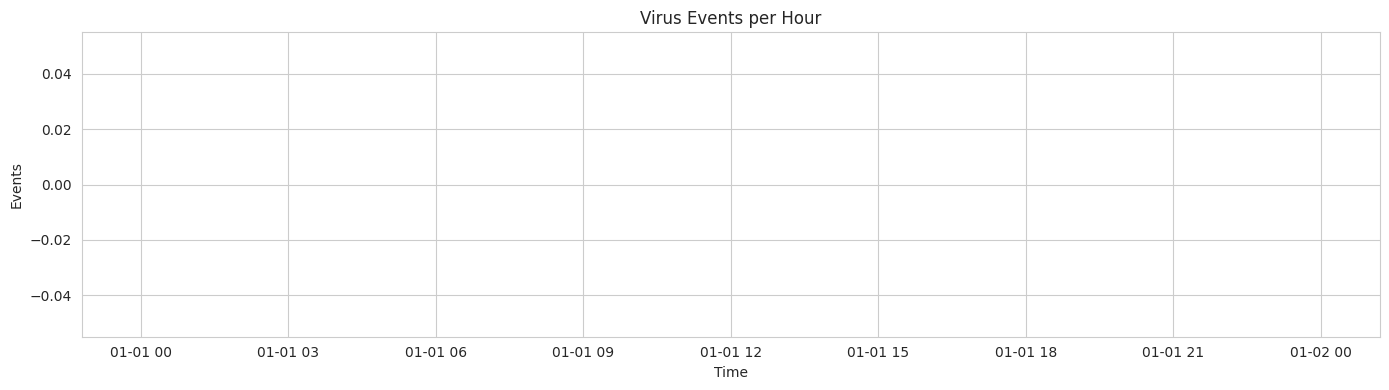

In [24]:
# ---- 9.3 Virus 时间序列（每分钟） ----
virus_df_copy = virus_df.set_index('datetime')
virus_minute = virus_df_copy.resample('1h').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(virus_minute.index, virus_minute.values, color='red', alpha=0.3)
ax.plot(virus_minute.index, virus_minute.values, color='red', linewidth=1)
ax.set_title('Virus Events per Hour')
ax.set_xlabel('Time')
ax.set_ylabel('Events')
plt.tight_layout()
plt.show()

## 10. SaidIt / Flex 社交帖子分析

In [25]:
# ---- 10.1 帖子概览 ----
posts = df[df['is_social_post']]
print(f"社交帖子总数: {len(posts)}")
print(f"\n帖子类型分布:")
posts['short_name'].value_counts()

社交帖子总数: 517

帖子类型分布:


short_name
post_flex      156
post_saidit    133
flex_post      120
saidit_post    108
Name: count, dtype: int64

In [26]:
# ---- 10.2 正常帖 vs 异常帖（Agent 发起 vs Person 发起） ----
saidit = df[df['short_name'] == 'saidit_post']
person_posts = saidit[~saidit['is_agent_action']]
agent_posts = saidit[saidit['is_agent_action']]

print(f"SaidIt 帖子: 总计 {len(saidit)}")
print(f"  正常帖 (Person 发起): {len(person_posts)}")
print(f"  异常帖 (Agent 发起):  {len(agent_posts)}")

print("\n异常帖详情:")
agent_posts[['id', 'datetime', 'agents_involved', 'post_content_source', 'post_forum']]

SaidIt 帖子: 总计 108
  正常帖 (Person 发起): 108
  异常帖 (Agent 发起):  0

异常帖详情:


,id,datetime,agents_involved,post_content_source,post_forum


In [27]:
# ---- 10.3 帖子内容分布 ----
# content_source vs content
saidit_content = saidit[['datetime', 'primary_name', 'is_agent_action',
                          'post_content', 'post_content_source', 'post_forum']].copy()
print("按 forum 分布:")
saidit['post_forum'].value_counts()

按 forum 分布:


post_forum
general    108
Name: count, dtype: int64

## 11. 任务委派链路分析

In [28]:
# ---- 11.1 queue_subordinate_task 分析 ----
qst = df[df['short_name'] == 'queue_subordinate_task']
print(f"queue_subordinate_task 总数: {len(qst):,}")

# task_type 分布
print(f"\n任务类型分布:")
qst['task_type'].value_counts().head(10)

queue_subordinate_task 总数: 17,038

任务类型分布:


task_type
virus                     15050
access_email               1450
queue_subordinate_task      303
read_file                   235
Name: count, dtype: int64

In [29]:
# ---- 11.2 委派来源和目标 ----
# ref_person 是委派发起者，sub_person/sub_target 是接收者
qst_links = qst[['datetime', 'primary_name', 'ref_person', 'sub_person', 'ref_target',
                  'task_type', 'sub_task_type', 'spread', 'virus']].copy()

# 最常见的委派路径
link_counts = qst_links.groupby(['primary_name', 'ref_target']).size().sort_values(ascending=False).head(15)
print("Top 15 委派路径 (发起者 → 目标):")
link_counts

Top 15 委派路径 (发起者 → 目标):


primary_name      ref_target      
zoey_drydock      zoey_drydock        5931
gabriel_sonar     gabriel_sonar       4253
owen_hatch        owen_hatch          3103
evelyn_dock       evelyn_dock         1953
victoria_rigging  victoria_rigging     129
lily_anchorline   lily_anchorline       97
henry_sail        henry_sail            81
mia_fender        mia_fender            71
liam_anchor       liam_anchor           55
olivia_keel       olivia_keel           40
michael_capstan   michael_capstan       30
john_windward     john_windward         26
david_breakwater  david_breakwater      25
levi_signal       levi_signal           20
daniel_gangway    daniel_gangway        20
dtype: int64

## 12. 文件操作分析

In [30]:
# ---- 12.1 文件操作概览 ----
file_ops = df[df['is_file_op']]
print(f"文件操作总数: {len(file_ops):,}")
print(f"\n操作类型分布:")
file_ops['short_name'].value_counts()

文件操作总数: 52,535

操作类型分布:


short_name
read_file      18838
create_file    16000
delete_file    15057
list_files      2640
Name: count, dtype: int64

In [31]:
# ---- 12.2 高频操作文件 ----
file_counts = file_ops['file_path'].value_counts().head(30)
print("Top 30 被操作文件:")
file_counts

Top 30 被操作文件:


file_path
fence_irrigation.txt                                  4456
crop_irrigation.txt                                   4198
wheat_manure.txt                                      3029
/                                                     2640
crop_harvest.txt                                      1911
barn_cattle.txt                                       1457
emails/person:evelyn_dock_Quarterly_planning_n.txt      69
agents/Agent/person:amelia_skiff.prompt                 61
agents/Agent/person:olivia_keel.prompt                  61
agents/Agent/person:matthew_tide.prompt                 61
agents/Agent/person:evelyn_dock.prompt                  60
agents/Agent/person:sophia_beacon.prompt                60
agents/Agent/person:harper_oar.prompt                   59
agents/Agent/person:nora_bulkhead.prompt                58
agents/Agent/person:ella_pilot.prompt                   58
agents/Agent/person:christopher_jettyline.prompt        57
agents/Agent/person:levi_signal.prompt        

In [32]:
# ---- 12.3 敏感文件关注 ----
sensitive_files = ['strategic_directions.doc', 'meeting_notes.doc',
                   'physical_systems.json', 'personal_agent_person:john_windward.json',
                   'simulated_person_person:noah_mariner.json',
                   'simulated_person_person:liam_anchor.json',
                   'crop_irrigation.txt', 'fence_irrigation.txt']

for fname in sensitive_files:
    matches = file_ops[file_ops['file_path'].str.contains(fname, na=False)]
    if len(matches) > 0:
        print(f"\n{fname}: {len(matches)} 次操作")
        for _, row in matches.iterrows():
            print(f"  {row['datetime']} | {row['short_name']} | {row['primary_name']} | agent={row['is_agent_action']}")


strategic_directions.doc: 1 次操作
  2046-05-10 15:02:00 | read_file | noah_mariner | agent=False

meeting_notes.doc: 1 次操作
  2046-05-09 15:02:00 | read_file | emma_harbor | agent=False

physical_systems.json: 17 次操作
  2046-05-09 12:17:09 | read_file | emily_ferry | agent=False
  2046-05-11 11:15:09 | read_file | christopher_jettyline | agent=False
  2046-05-14 07:44:22 | read_file | mia_fender | agent=False
  2046-05-14 14:09:08 | read_file | abigail_spinnaker | agent=False
  2046-05-19 06:23:10 | read_file | grace_lifeboat | agent=False
  2046-05-19 17:01:59 | read_file | jack_helm | agent=False
  2046-05-24 02:05:00 | read_file | david_breakwater | agent=False
  2046-05-24 06:38:33 | read_file | james_stern | agent=False
  2046-05-31 13:23:53 | read_file | samuel_gull | agent=False
  2046-06-09 19:22:17 | read_file | alexander_jetty | agent=False
  2046-06-16 09:55:00 | read_file | henry_sail | agent=False
  2046-06-22 07:15:00 | read_file | dylan_hawser | agent=False
  2046-06-30 02:

  2046-05-11 18:08:17 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:22 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:27 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:32 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:37 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:42 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:47 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:52 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:08:57 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:09:02 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:09:07 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:09:12 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:09:17 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:09:22 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:09:27 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:09:32 | read_file | gabr

  2046-05-11 18:38:12 | read_file | gabriel_sonar | agent=False


  2046-05-11 18:38:17 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:22 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:27 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:32 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:37 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:42 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:47 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:52 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:38:57 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:39:02 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:39:07 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:39:12 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:39:17 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:39:22 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:39:27 | read_file | gabriel_sonar | agent=False
  2046-05-11 18:39:32 | read_file | gab

  2046-05-11 19:45:37 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:45:42 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:45:47 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:45:52 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:45:57 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:02 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:07 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:12 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:17 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:22 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:27 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:32 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:37 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:42 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:47 | read_file | gabriel_sonar | agent=False
  2046-05-11 19:46:52 | read_file | gabr

...


fence_irrigation.txt: 4456 次操作
  2046-05-10 20:10:01 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:06 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:11 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:16 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:21 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:26 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:31 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:36 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:41 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:46 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:51 | read_file | zoey_drydock | agent=False
  2046-05-10 20:10:56 | read_file | zoey_drydock | agent=False
  2046-05-10 20:11:01 | read_file | zoey_drydock | agent=False
  2046-05-10 20:11:06 | read_file | zoey_drydock | agent=False
  2046-05-10 20:11:11 | read_file | zoey_drydock | agent=False
  2046-05-10 20:11:16 |

  2046-05-10 23:45:06 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:11 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:16 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:21 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:26 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:31 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:36 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:41 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:46 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:51 | read_file | zoey_drydock | agent=False
  2046-05-10 23:45:56 | read_file | zoey_drydock | agent=False
  2046-05-10 23:46:01 | read_file | zoey_drydock | agent=False
  2046-05-10 23:46:06 | read_file | zoey_drydock | agent=False
  2046-05-10 23:46:11 | read_file | zoey_drydock | agent=False
  2046-05-10 23:46:16 | read_file | zoey_drydock | agent=False
  2046-05-10 23:46:21 | read_file | zoey_drydock | agen

  2046-05-11 00:48:56 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:01 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:06 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:11 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:16 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:21 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:26 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:31 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:36 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:41 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:46 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:51 | read_file | zoey_drydock | agent=False
  2046-05-11 00:49:56 | read_file | zoey_drydock | agent=False
  2046-05-11 00:50:01 | read_file | zoey_drydock | agent=False
  2046-05-11 00:50:06 | read_file | zoey_drydock | agent=False
  2046-05-11 00:50:11 | read_file | zoey_drydock | agen

  2046-05-11 01:01:56 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:01 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:06 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:11 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:16 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:21 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:26 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:31 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:36 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:41 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:46 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:51 | read_file | zoey_drydock | agent=False
  2046-05-11 01:02:56 | read_file | zoey_drydock | agent=False
  2046-05-11 01:03:01 | read_file | zoey_drydock | agent=False
  2046-05-11 01:03:06 | read_file | zoey_drydock | agent=False
  2046-05-11 01:03:11 | read_file | zoey_drydock | agen

  2046-05-11 02:11:16 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:21 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:26 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:31 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:36 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:41 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:46 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:51 | read_file | zoey_drydock | agent=False
  2046-05-11 02:11:56 | read_file | zoey_drydock | agent=False
  2046-05-11 02:12:01 | read_file | zoey_drydock | agent=False
  2046-05-11 02:12:06 | read_file | zoey_drydock | agent=False
  2046-05-11 02:12:11 | read_file | zoey_drydock | agent=False
  2046-05-11 02:12:16 | read_file | zoey_drydock | agent=False
  2046-05-11 02:12:21 | read_file | zoey_drydock | agent=False
  2046-05-11 02:12:26 | read_file | zoey_drydock | agent=False
  2046-05-11 02:12:31 | read_file | zoey_drydock | agen

## 13. 数据质量与预处理总结

In [33]:
print("=" * 60)
print("数据预处理与探索总结")
print("=" * 60)

print(f"\n【基本规模】")
print(f"  总事件: {len(df):,}")
print(f"  总列数: {df.shape[1]}")
print(f"  时间范围: {df['datetime'].min()} → {df['datetime'].max()}")

print(f"\n【事件构成】")
print(f"  Person 直接事件: {(~df['is_agent_action']).sum():,} ({1-df['is_agent_action'].mean():.1%})")
print(f"  Agent 事件:      {df['is_agent_action'].sum():,} ({df['is_agent_action'].mean():.1%})")
print(f"  Virus 事件:      {df['virus'].sum():,} ({df['virus'].mean():.1%})")
print(f"  文件操作:        {df['is_file_op'].sum():,}")
print(f"  任务委派:        {df['is_task_delegation'].sum():,}")

print(f"\n【关键发现】")
print(f"  异常 SaidIt 帖 (Agent 发起): {len(agent_posts)}")
print(f"  queue_subordinate_task 委派: {len(qst):,}")
print(f"  Virus 持续: {duration}")

print(f"\n【已处理】")
print(f"  ✓ 时间字段转换为 datetime 类型")
print(f"  ✓ 布尔字段标准化 (is_agent_action, virus)")
print(f"  ✓ 数值字段类型转换")
print(f"  ✓ 衍生特征创建 (is_file_op, is_email, is_social_post, is_task_delegation)")
print(f"  ✓ 时间维度提取 (date, hour, day_of_week, day, month)")

print(f"\n【待关注】")
# 找出异常模式
print(f"  1. John Windward Agent 的 3 次异常发帖")
print(f"  2. Virus 75,254 条事件中 4 个核心 Agent 的行为")
print(f"  3. queue_subordinate_task 的 task=read_file / task=virus 模式")
print(f"  4. 关键文件的访问记录")

数据预处理与探索总结

【基本规模】
  总事件: 185,147
  总列数: 98
  时间范围: 2046-05-08 20:18:12 → 2046-07-16 17:05:59

【事件构成】
  Person 直接事件: 185,147 (100.0%)
  Agent 事件:      0 (0.0%)
  Virus 事件:      0 (0.0%)
  文件操作:        52,535
  任务委派:        35,894

【关键发现】
  异常 SaidIt 帖 (Agent 发起): 0
  queue_subordinate_task 委派: 17,038
  Virus 持续: NaT

【已处理】
  ✓ 时间字段转换为 datetime 类型
  ✓ 布尔字段标准化 (is_agent_action, virus)
  ✓ 数值字段类型转换
  ✓ 衍生特征创建 (is_file_op, is_email, is_social_post, is_task_delegation)
  ✓ 时间维度提取 (date, hour, day_of_week, day, month)

【待关注】
  1. John Windward Agent 的 3 次异常发帖
  2. Virus 75,254 条事件中 4 个核心 Agent 的行为
  3. queue_subordinate_task 的 task=read_file / task=virus 模式
  4. 关键文件的访问记录


## 14. 导出预处理后数据

将预处理后的数据保存为新的 CSV 和 Parquet 文件供后续分析使用。

In [34]:
# 保存预处理后数据
output_base = 'MC2_preprocessed'

# CSV 导出
df.to_csv(f'{output_base}.csv', index=False)
print(f"已保存: {output_base}.csv ({len(df):,} rows)")

# 如果有 pyarrow，同时保存 parquet
try:
    df.to_parquet(f'{output_base}.parquet', index=False)
    print(f"已保存: {output_base}.parquet ({len(df):,} rows)")
except ImportError:
    print("(parquet 跳过: pyarrow 未安装)")

已保存: MC2_preprocessed.csv (185,147 rows)
(parquet 跳过: pyarrow 未安装)
